In [1]:
# Block 1 — setup + read IPUMS XML schema + read raw .dat
import xml.etree.ElementTree as ET
from pyspark.sql import SparkSession, functions as F

#spark = SparkSession.builder.getOrCreate()

spark = SparkSession.builder \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "18g") \
    .config("spark.executor.instances", 7) \
    .getOrCreate()

xml_path = "../../evargasnavarro/shared/processed/usa_00001.xml"
dat_path = "../../evargasnavarro/shared/processed/usa_00001.dat"

# Parse IPUMS DDI XML for fixed-width specs
ns = {"ddi": "ddi:codebook:2_5"}
root = ET.parse(xml_path).getroot()

specs = []
for var in root.findall(".//ddi:dataDscr/ddi:var", ns):
    loc = var.find("ddi:location", ns)
    fmt = var.find("ddi:varFormat", ns)
    specs.append({
        "name": var.attrib["name"],
        "start": int(loc.attrib["StartPos"]),
        "width": int(loc.attrib["width"]),
        "dcml": int(var.attrib.get("dcml", "0")),
        "type": fmt.attrib.get("type", "character") if fmt is not None else "character"
    })

raw_df = spark.read.text(dat_path)
raw_df.show(5, truncate=False)  # raw fixed-width lines
print(f"Columns in XML spec: {len(specs)}")

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [2]:
# Block 2 — parse to Spark DataFrame + cast numerics + inspect
df = raw_df.select(*[
    F.substring("value", s["start"], s["width"]).alias(s["name"])
    for s in specs
])

for s in specs:
    if s["type"] == "numeric":
        df = df.withColumn(s["name"], F.col(s["name"]).cast("double"))
        if s["dcml"] > 0:
            df = df.withColumn(s["name"], F.col(s["name"]) / (10 ** s["dcml"]))


#df.show(10, truncate=False)

# Train Your Second Model using Dimensionality Reduction

The plan is to use PCA and train a second model on the reduced-dimension features.

## Redoing Data Preprocessing
Because we will be performing dimensionality reduction with PCA, we should add more columns from the original dataset. This section will effectively be a repeat of the data-preprocessing.ipynb notebook. The extra columns I will add are the following:
-  EMPSTAT (Categorical): Employment status
-  CITIZEN (Categorical): Citizenship status
-  WKSWORK1 (Categorical): Number of weeks worked in the past year
-  MARRINYR (Categorical): If the respondent has been married in the past year.
-  HISPAN (Categorical): Hispanic Origin

Again, all encodings can be found on the [IPUMS website](https://usa.ipums.org/usa-action/variables/search)

While we would like to use more specific occupations in the OCC1990 column, there are simply too many categories (~400 categories) which would make a matrix that is too sparse to be useful.

In [3]:
df = df.select("YEAR", "STATEFIP", "SEX", "AGE", "RACE", "EDUC", "INCTOT", "CPI99", "EMPSTAT", "CITIZEN", "WKSWORK1", "MARRINYR", "HISPAN")


Check for nulls in the new columns

In [4]:
all_null_counts = df.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in ["EMPSTAT", "CITIZEN", "WKSWORK1", "MARRINYR", "HISPAN"]])
all_null_counts.show(truncate=False)

+-------+-------+--------+--------+------+
|EMPSTAT|CITIZEN|WKSWORK1|MARRINYR|HISPAN|
+-------+-------+--------+--------+------+
|0      |0      |34291600|13498899|0     |
+-------+-------+--------+--------+------+



Check counts for unique values

In [5]:
df.groupBy("EMPSTAT").count().sort("EMPSTAT").show(df.count(), truncate=False)

+-------+--------+
|EMPSTAT|count   |
+-------+--------+
|0.0    |12563134|
|1.0    |30969836|
|2.0    |2064390 |
|3.0    |21528420|
+-------+--------+



In [6]:
df.groupBy("CITIZEN").count().sort("CITIZEN").show(df.count(), truncate=False)

+-------+--------+
|CITIZEN|count   |
+-------+--------+
|0.0    |58913101|
|1.0    |584652  |
|2.0    |3974012 |
|3.0    |3654015 |
+-------+--------+



In [7]:
df.groupBy("WKSWORK1").count().sort("WKSWORK1").show(df.count(), truncate=False)

+--------+--------+
|WKSWORK1|count   |
+--------+--------+
|NULL    |34291600|
|0.0     |15627774|
|1.0     |110813  |
|2.0     |125829  |
|3.0     |106287  |
|4.0     |172820  |
|5.0     |69359   |
|6.0     |102094  |
|7.0     |30439   |
|8.0     |154797  |
|9.0     |32194   |
|10.0    |126100  |
|11.0    |17865   |
|12.0    |261137  |
|13.0    |33048   |
|14.0    |39175   |
|15.0    |61640   |
|16.0    |125624  |
|17.0    |19475   |
|18.0    |36724   |
|19.0    |8924    |
|20.0    |238720  |
|21.0    |18956   |
|22.0    |32354   |
|23.0    |13544   |
|24.0    |131727  |
|25.0    |93441   |
|26.0    |185090  |
|27.0    |16490   |
|28.0    |83216   |
|29.0    |11767   |
|30.0    |210598  |
|31.0    |9707    |
|32.0    |127784  |
|33.0    |14592   |
|34.0    |27873   |
|35.0    |75898   |
|36.0    |186356  |
|37.0    |22953   |
|38.0    |56098   |
|39.0    |30757   |
|40.0    |478140  |
|41.0    |18414   |
|42.0    |101977  |
|43.0    |29035   |
|44.0    |127166  |
|45.0    |141485  |


In [8]:
df.groupBy("MARRINYR").count().sort("MARRINYR").show(df.count(), truncate=False)

+--------+--------+
|MARRINYR|count   |
+--------+--------+
|NULL    |13498899|
|0.0     |9022898 |
|1.0     |43894227|
|2.0     |709756  |
+--------+--------+



In [9]:
df.groupBy("HISPAN").count().sort("HISPAN").show(df.count(), truncate=False)

+------+--------+
|HISPAN|count   |
+------+--------+
|0.0   |57918473|
|1.0   |5747698 |
|2.0   |845379  |
|3.0   |373322  |
|4.0   |2240908 |
+------+--------+



Designate code specific missing values as NaNs.

In [10]:
df = df.replace(0, None, subset=["EMPSTAT"])
df = df.replace(0, None, subset=["CITIZEN"])
df = df.replace(0, None, subset=["MARRINYR"])

In [11]:
df.show(5)

+------+--------+---+----+----+----+---------+-----+-------+-------+--------+--------+------+
|  YEAR|STATEFIP|SEX| AGE|RACE|EDUC|   INCTOT|CPI99|EMPSTAT|CITIZEN|WKSWORK1|MARRINYR|HISPAN|
+------+--------+---+----+----+----+---------+-----+-------+-------+--------+--------+------+
|2001.0|     1.0|1.0|39.0| 1.0| 3.0|   6400.0|0.941|    3.0|   NULL|     0.0|    NULL|   0.0|
|2001.0|     1.0|1.0|33.0| 2.0|10.0|  30000.0|0.941|    1.0|   NULL|    52.0|    NULL|   0.0|
|2001.0|     1.0|2.0|40.0| 1.0| 6.0|  16500.0|0.941|    1.0|   NULL|    52.0|    NULL|   0.0|
|2001.0|     1.0|1.0|10.0| 1.0| 1.0|9999999.0|0.941|   NULL|   NULL|     0.0|    NULL|   0.0|
|2001.0|     1.0|2.0|21.0| 1.0| 3.0|      0.0|0.941|    2.0|   NULL|     0.0|    NULL|   0.0|
+------+--------+---+----+----+----+---------+-----+-------+-------+--------+--------+------+
only showing top 5 rows



For missing data in categorical columns, we will impute with the mode.

In [12]:
#null_fill = df.groupBy("EMPSTAT").count().orderBy(F.col("count").desc()).first()[0]
df = df.fillna(1, subset=["EMPSTAT"])

#null_fill = df.groupBy("CITIZEN").count().orderBy(F.col("count").desc()).first()[0]
df = df.fillna(2, subset=["CITIZEN"])

#null_fill = df.groupBy("MARRINYR").count().orderBy(F.col("count").desc()).first()[0]
df = df.fillna(1, subset=["MARRINYR"])
df.show(5)

+------+--------+---+----+----+----+---------+-----+-------+-------+--------+--------+------+
|  YEAR|STATEFIP|SEX| AGE|RACE|EDUC|   INCTOT|CPI99|EMPSTAT|CITIZEN|WKSWORK1|MARRINYR|HISPAN|
+------+--------+---+----+----+----+---------+-----+-------+-------+--------+--------+------+
|2001.0|     1.0|1.0|39.0| 1.0| 3.0|   6400.0|0.941|    3.0|    2.0|     0.0|     1.0|   0.0|
|2001.0|     1.0|1.0|33.0| 2.0|10.0|  30000.0|0.941|    1.0|    2.0|    52.0|     1.0|   0.0|
|2001.0|     1.0|2.0|40.0| 1.0| 6.0|  16500.0|0.941|    1.0|    2.0|    52.0|     1.0|   0.0|
|2001.0|     1.0|1.0|10.0| 1.0| 1.0|9999999.0|0.941|    1.0|    2.0|     0.0|     1.0|   0.0|
|2001.0|     1.0|2.0|21.0| 1.0| 3.0|      0.0|0.941|    2.0|    2.0|     0.0|     1.0|   0.0|
+------+--------+---+----+----+----+---------+-----+-------+-------+--------+--------+------+
only showing top 5 rows



For missing data in numeric columns, we will impute with the mean

In [13]:
mean_val = df.select(F.mean("WKSWORK1")).collect()[0][0]
df = df.fillna(mean_val, subset=["WKSWORK1"])

In [14]:
df.show(5)

+------+--------+---+----+----+----+---------+-----+-------+-------+--------+--------+------+
|  YEAR|STATEFIP|SEX| AGE|RACE|EDUC|   INCTOT|CPI99|EMPSTAT|CITIZEN|WKSWORK1|MARRINYR|HISPAN|
+------+--------+---+----+----+----+---------+-----+-------+-------+--------+--------+------+
|2001.0|     1.0|1.0|39.0| 1.0| 3.0|   6400.0|0.941|    3.0|    2.0|     0.0|     1.0|   0.0|
|2001.0|     1.0|1.0|33.0| 2.0|10.0|  30000.0|0.941|    1.0|    2.0|    52.0|     1.0|   0.0|
|2001.0|     1.0|2.0|40.0| 1.0| 6.0|  16500.0|0.941|    1.0|    2.0|    52.0|     1.0|   0.0|
|2001.0|     1.0|1.0|10.0| 1.0| 1.0|9999999.0|0.941|    1.0|    2.0|     0.0|     1.0|   0.0|
|2001.0|     1.0|2.0|21.0| 1.0| 3.0|      0.0|0.941|    2.0|    2.0|     0.0|     1.0|   0.0|
+------+--------+---+----+----+----+---------+-----+-------+-------+--------+--------+------+
only showing top 5 rows



Since most of the categorical data already have the desired numeric scaling or ordinal encoding, we can directly apply min-max scaling. We use this over Z-score scaling because there are defined ranges for each column. 

In [15]:
from pyspark.ml.feature import MinMaxScaler, VectorAssembler

assembler = VectorAssembler(inputCols=["EMPSTAT"], outputCol="EMPSTAT_VEC")
df = assembler.transform(df)

# EMPSTAT (MM for min-max)
scaler = MinMaxScaler(inputCol="EMPSTAT_VEC", outputCol="EMPSTAT_MM")
scalerModel = scaler.fit(df)
df = scalerModel.transform(df)

# CITIZEN
assembler = VectorAssembler(inputCols=["CITIZEN"], outputCol="CITIZEN_VEC")
df = assembler.transform(df)

scaler = MinMaxScaler(inputCol="CITIZEN_VEC", outputCol="CITIZEN_MM")
scalerModel = scaler.fit(df)
df = scalerModel.transform(df)

# MARRINYR (We can simply subtract one from everything since it's effectively a binary encoding)
df = df.withColumn("MARRINYR_MM", F.col("MARRINYR") - 1)

# WKSWORK1
assembler = VectorAssembler(inputCols=["WKSWORK1"], outputCol="WKSWORK1_VEC")
df = assembler.transform(df)

scaler = MinMaxScaler(inputCol="WKSWORK1_VEC", outputCol="WKSWORK1_MM")
scalerModel = scaler.fit(df)
df = scalerModel.transform(df)

df = df.drop("EMPSTAT_VEC", "CITIZEN_VEC", "WKSWORK1_VEC")

In [16]:
df.show(5)

+------+--------+---+----+----+----+---------+-----+-------+-------+--------+--------+------+----------+----------+-----------+-----------+
|  YEAR|STATEFIP|SEX| AGE|RACE|EDUC|   INCTOT|CPI99|EMPSTAT|CITIZEN|WKSWORK1|MARRINYR|HISPAN|EMPSTAT_MM|CITIZEN_MM|MARRINYR_MM|WKSWORK1_MM|
+------+--------+---+----+----+----+---------+-----+-------+-------+--------+--------+------+----------+----------+-----------+-----------+
|2001.0|     1.0|1.0|39.0| 1.0| 3.0|   6400.0|0.941|    3.0|    2.0|     0.0|     1.0|   0.0|     [1.0]|     [0.5]|        0.0|      [0.0]|
|2001.0|     1.0|1.0|33.0| 2.0|10.0|  30000.0|0.941|    1.0|    2.0|    52.0|     1.0|   0.0|     [0.0]|     [0.5]|        0.0|      [1.0]|
|2001.0|     1.0|2.0|40.0| 1.0| 6.0|  16500.0|0.941|    1.0|    2.0|    52.0|     1.0|   0.0|     [0.0]|     [0.5]|        0.0|      [1.0]|
|2001.0|     1.0|1.0|10.0| 1.0| 1.0|9999999.0|0.941|    1.0|    2.0|     0.0|     1.0|   0.0|     [0.0]|     [0.5]|        0.0|      [0.0]|
|2001.0|     1.0|2.0

For the HISPAN column, ther is no valid ordinal encoding, so we'll use a basic one hot encoding. Since it already has a valid indexing, we don't need to use StringIndexer.

In [17]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline


encoder = OneHotEncoder(inputCol="HISPAN", outputCol="HISPAN_OH", dropLast=False)
model = encoder.fit(df)
df = model.transform(df)

In [18]:
df.show(5)

+------+--------+---+----+----+----+---------+-----+-------+-------+--------+--------+------+----------+----------+-----------+-----------+-------------+
|  YEAR|STATEFIP|SEX| AGE|RACE|EDUC|   INCTOT|CPI99|EMPSTAT|CITIZEN|WKSWORK1|MARRINYR|HISPAN|EMPSTAT_MM|CITIZEN_MM|MARRINYR_MM|WKSWORK1_MM|    HISPAN_OH|
+------+--------+---+----+----+----+---------+-----+-------+-------+--------+--------+------+----------+----------+-----------+-----------+-------------+
|2001.0|     1.0|1.0|39.0| 1.0| 3.0|   6400.0|0.941|    3.0|    2.0|     0.0|     1.0|   0.0|     [1.0]|     [0.5]|        0.0|      [0.0]|(5,[0],[1.0])|
|2001.0|     1.0|1.0|33.0| 2.0|10.0|  30000.0|0.941|    1.0|    2.0|    52.0|     1.0|   0.0|     [0.0]|     [0.5]|        0.0|      [1.0]|(5,[0],[1.0])|
|2001.0|     1.0|2.0|40.0| 1.0| 6.0|  16500.0|0.941|    1.0|    2.0|    52.0|     1.0|   0.0|     [0.0]|     [0.5]|        0.0|      [1.0]|(5,[0],[1.0])|
|2001.0|     1.0|1.0|10.0| 1.0| 1.0|9999999.0|0.941|    1.0|    2.0|     0.0

### Preprocessing original columns
From here, most of the preprocessing steps are the same. The only exception is that in calculating REALINCTOT_Z, a log scale will be applied before Z score normalization.

### Processing INCTOT

In [19]:
df = df.replace(9999999.0, None, subset=["INCTOT"]) #Exclude missing values from average calculations
df.show(10)

+------+--------+---+----+----+----+-------+-----+-------+-------+--------+--------+------+----------+----------+-----------+-----------+-------------+
|  YEAR|STATEFIP|SEX| AGE|RACE|EDUC| INCTOT|CPI99|EMPSTAT|CITIZEN|WKSWORK1|MARRINYR|HISPAN|EMPSTAT_MM|CITIZEN_MM|MARRINYR_MM|WKSWORK1_MM|    HISPAN_OH|
+------+--------+---+----+----+----+-------+-----+-------+-------+--------+--------+------+----------+----------+-----------+-----------+-------------+
|2001.0|     1.0|1.0|39.0| 1.0| 3.0| 6400.0|0.941|    3.0|    2.0|     0.0|     1.0|   0.0|     [1.0]|     [0.5]|        0.0|      [0.0]|(5,[0],[1.0])|
|2001.0|     1.0|1.0|33.0| 2.0|10.0|30000.0|0.941|    1.0|    2.0|    52.0|     1.0|   0.0|     [0.0]|     [0.5]|        0.0|      [1.0]|(5,[0],[1.0])|
|2001.0|     1.0|2.0|40.0| 1.0| 6.0|16500.0|0.941|    1.0|    2.0|    52.0|     1.0|   0.0|     [0.0]|     [0.5]|        0.0|      [1.0]|(5,[0],[1.0])|
|2001.0|     1.0|1.0|10.0| 1.0| 1.0|   NULL|0.941|    1.0|    2.0|     0.0|     1.0|   0

In [20]:
income_averages = df.select("YEAR", "INCTOT").groupBy("YEAR").agg(F.avg("INCTOT").alias("INCTOT_AVG"))
income_averages = income_averages.select("YEAR", "INCTOT_AVG").rdd.collectAsMap()
income_averages #averages per year

{2001.0: 29386.547426435278,
 2002.0: 29917.722725334796,
 2003.0: 29942.784641597074,
 2004.0: 31199.262673265664,
 2005.0: 32081.598902228532,
 2006.0: 32496.915978168345,
 2007.0: 34351.79880858902,
 2008.0: 35465.87360155502,
 2009.0: 34661.97982040677,
 2010.0: 33779.009013067865,
 2011.0: 32768.56448544411,
 2012.0: 34117.01523478559,
 2013.0: 35747.96799509845,
 2014.0: 36528.664186469454,
 2015.0: 38276.89470220228,
 2016.0: 39487.482940526665,
 2017.0: 40832.207084073074,
 2018.0: 42496.599239466035,
 2019.0: 45302.28290449767,
 2020.0: 44912.61504463044,
 2021.0: 46295.92238451688,
 2022.0: 49422.73825908559,
 2023.0: 52133.932345992565,
 2024.0: 54654.70966942347}

In [21]:
for key, val in income_averages.items():
    df = df.withColumn("INCTOT", F.when((F.col("YEAR") == key) & (F.col("INCTOT").isNull()), val).otherwise(F.col("INCTOT")))
df.show(10)

+------+--------+---+----+----+----+------------------+-----+-------+-------+--------+--------+------+----------+----------+-----------+-----------+-------------+
|  YEAR|STATEFIP|SEX| AGE|RACE|EDUC|            INCTOT|CPI99|EMPSTAT|CITIZEN|WKSWORK1|MARRINYR|HISPAN|EMPSTAT_MM|CITIZEN_MM|MARRINYR_MM|WKSWORK1_MM|    HISPAN_OH|
+------+--------+---+----+----+----+------------------+-----+-------+-------+--------+--------+------+----------+----------+-----------+-----------+-------------+
|2001.0|     1.0|1.0|39.0| 1.0| 3.0|            6400.0|0.941|    3.0|    2.0|     0.0|     1.0|   0.0|     [1.0]|     [0.5]|        0.0|      [0.0]|(5,[0],[1.0])|
|2001.0|     1.0|1.0|33.0| 2.0|10.0|           30000.0|0.941|    1.0|    2.0|    52.0|     1.0|   0.0|     [0.0]|     [0.5]|        0.0|      [1.0]|(5,[0],[1.0])|
|2001.0|     1.0|2.0|40.0| 1.0| 6.0|           16500.0|0.941|    1.0|    2.0|    52.0|     1.0|   0.0|     [0.0]|     [0.5]|        0.0|      [1.0]|(5,[0],[1.0])|
|2001.0|     1.0|1.0|1

### Adjusting for inflation and applying log scaling (NEW)
As a change from the previous data preprocessing, we will apply a logarithm to the REALINCTOT column due to its rightward skewing distribution. There are negative values, so we'll do a signed version. We will still keep the original REALINCTOT as that will be a label column for one of our models.

In [22]:
df = df.withColumn("REALINCTOT", F.col("INCTOT") * F.col("CPI99"))
df = df.withColumn("REALINCTOT_LOG", F.signum(F.col("REALINCTOT")) * F.log1p(F.abs(F.col("REALINCTOT"))))
df = df.drop("CPI99") # No longer need CPI column
df.show(10)

+------+--------+---+----+----+----+------------------+-------+-------+--------+--------+------+----------+----------+-----------+-----------+-------------+------------------+-----------------+
|  YEAR|STATEFIP|SEX| AGE|RACE|EDUC|            INCTOT|EMPSTAT|CITIZEN|WKSWORK1|MARRINYR|HISPAN|EMPSTAT_MM|CITIZEN_MM|MARRINYR_MM|WKSWORK1_MM|    HISPAN_OH|        REALINCTOT|   REALINCTOT_LOG|
+------+--------+---+----+----+----+------------------+-------+-------+--------+--------+------+----------+----------+-----------+-----------+-------------+------------------+-----------------+
|2001.0|     1.0|1.0|39.0| 1.0| 3.0|            6400.0|    3.0|    2.0|     0.0|     1.0|   0.0|     [1.0]|     [0.5]|        0.0|      [0.0]|(5,[0],[1.0])|            6022.4|8.703407162925537|
|2001.0|     1.0|1.0|33.0| 2.0|10.0|           30000.0|    1.0|    2.0|    52.0|     1.0|   0.0|     [0.0]|     [0.5]|        0.0|      [1.0]|(5,[0],[1.0])|           28230.0|10.24817594392868|
|2001.0|     1.0|2.0|40.0| 1.0

### Mapping Categorical Mappings to New Columns
We will apply the mappings provided by IPUMS to create qualitiative columns

In [23]:
statefip = {
    1: "Alabama",
    2: "Alaska",
    4: "Arizona",
    5: "Arkansas",
    6: "California",
    8: "Colorado",
    9: "Connecticut",
    10: "Delaware",
    11: "District of Columbia",
    12: "Florida",
    13: "Georgia",
    15: "Hawaii",
    16: "Idaho",
    17: "Illinois",
    18: "Indiana",
    19: "Iowa",
    20: "Kansas",
    21: "Kentucky",
    22: "Louisiana",
    23: "Maine",
    24: "Maryland",
    25: "Massachusetts",
    26: "Michigan",
    27: "Minnesota",
    28: "Mississippi",
    29: "Missouri",
    30: "Montana",
    31: "Nebraska",
    32: "Nevada",
    33: "New Hampshire",
    34: "New Jersey",
    35: "New Mexico",
    36: "New York",
    37: "North Carolina",
    38: "North Dakota",
    39: "Ohio",
    40: "Oklahoma",
    41: "Oregon",
    42: "Pennsylvania",
    44: "Rhode Island",
    45: "South Carolina",
    46: "South Dakota",
    47: "Tennessee",
    48: "Texas",
    49: "Utah",
    50: "Vermont",
    51: "Virginia",
    53: "Washington",
    54: "West Virginia",
    55: "Wisconsin",
    56: "Wyoming",
    72: "Puerto Rico",
    99: "State not identified"
}
sex = {
    1: "Male", 
    2: "Female", 
    9: "Missing/blank"
}
race = {
    1: "White", 
    2: "Black/African American", 
    3: "American Indian or Alaska Native", 
    4: "Chinese", 
    5: "Japanese", 
    6: "Other Asian or Pacific Islander", 
    7: "Other race, nec", 
    8: "Two major races", 
    9: "Three or more major races"
}
educ = {
    0: "N/A or no schooling", 
    1: "Nursery school to grade 4", 
    2: "Grade 5, 6, 7, or 8", 
    3: "Grade 9", 
    4: "Grade 10", 
    5: "Grade 11", 
    6: "Grade 12", 
    7: "1 year of college", 
    8: "2 years of college", 
    9: "3 years of college", 
    10: "4 years of college", 
    11: "5+ years of college", 
    99: "Missing"
}

In [24]:
# State
state_mapping = [F.lit(x) for item in statefip.items() for x in item]
df = df.withColumn("STATENAME", F.create_map(state_mapping)[F.col("STATEFIP")])

# Sex
sex_mapping = [F.lit(x) for item in sex.items() for x in item]
df = df.withColumn("SEXNAME", F.create_map(sex_mapping)[F.col("SEX")])

# Race
race_mapping = [F.lit(x) for item in race.items() for x in item]
df = df.withColumn("RACENAME", F.create_map(race_mapping)[F.col("RACE")])

# Educ
educ_mapping = [F.lit(x) for item in educ.items() for x in item]
df = df.withColumn("EDUCNAME", F.create_map(educ_mapping)[F.col("EDUC")])

df.show(10)

+------+--------+---+----+----+----+------------------+-------+-------+--------+--------+------+----------+----------+-----------+-----------+-------------+------------------+-----------------+---------+-------+--------------------+--------------------+
|  YEAR|STATEFIP|SEX| AGE|RACE|EDUC|            INCTOT|EMPSTAT|CITIZEN|WKSWORK1|MARRINYR|HISPAN|EMPSTAT_MM|CITIZEN_MM|MARRINYR_MM|WKSWORK1_MM|    HISPAN_OH|        REALINCTOT|   REALINCTOT_LOG|STATENAME|SEXNAME|            RACENAME|            EDUCNAME|
+------+--------+---+----+----+----+------------------+-------+-------+--------+--------+------+----------+----------+-----------+-----------+-------------+------------------+-----------------+---------+-------+--------------------+--------------------+
|2001.0|     1.0|1.0|39.0| 1.0| 3.0|            6400.0|    3.0|    2.0|     0.0|     1.0|   0.0|     [1.0]|     [0.5]|        0.0|      [0.0]|(5,[0],[1.0])|            6022.4|8.703407162925537|  Alabama|   Male|               White|      

### Encoding Categorical Data
We will One-Hot encode the data in the categorical columns "STATEFIP", "SEX", and "RACE" due to their unranked nature. Unfortunately, we cannot use the raw numbers as indexes because the code scheme has many unused intermediate numbers like 3 for "STATEFIP" which will lead to unused indexes and overly sparse arrays. We will instead use the newly created categorical columns to create a new index column and then conver these indexes to One-Hot encodings.

In [25]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline

#OH for One-Hot
pairs = [("STATENAME", "STATE_INDEX", "STATE_OH"), 
         ("SEXNAME", "SEX_INDEX", "SEX_OH"), 
         ("RACENAME", "RACE_INDEX", "RACE_OH")]
steps = []
for in_col, mid_col, out_col in pairs:
    indexer = StringIndexer(inputCol=in_col, outputCol=mid_col)
    steps.append(indexer)
    encoder = OneHotEncoder(inputCol=mid_col, outputCol=out_col, dropLast=False)
    steps.append(encoder)
    
pipeline = Pipeline(stages=steps)
model = pipeline.fit(df)
df = model.transform(df)

df = df.drop("STATE_INDEX", "SEX_INDEX", "RACE_INDEX")
df.select("STATENAME", "STATE_OH", "SEXNAME", "SEX_OH", "RACENAME", "RACE_OH").show(10)

+---------+---------------+-------+-------------+--------------------+-------------+
|STATENAME|       STATE_OH|SEXNAME|       SEX_OH|            RACENAME|      RACE_OH|
+---------+---------------+-------+-------------+--------------------+-------------+
|  Alabama|(51,[22],[1.0])|   Male|(2,[1],[1.0])|               White|(9,[0],[1.0])|
|  Alabama|(51,[22],[1.0])|   Male|(2,[1],[1.0])|Black/African Ame...|(9,[1],[1.0])|
|  Alabama|(51,[22],[1.0])| Female|(2,[0],[1.0])|               White|(9,[0],[1.0])|
|  Alabama|(51,[22],[1.0])|   Male|(2,[1],[1.0])|               White|(9,[0],[1.0])|
|  Alabama|(51,[22],[1.0])| Female|(2,[0],[1.0])|               White|(9,[0],[1.0])|
|  Alabama|(51,[22],[1.0])|   Male|(2,[1],[1.0])|               White|(9,[0],[1.0])|
|  Alabama|(51,[22],[1.0])| Female|(2,[0],[1.0])|               White|(9,[0],[1.0])|
|  Alabama|(51,[22],[1.0])|   Male|(2,[1],[1.0])|               White|(9,[0],[1.0])|
|  Alabama|(51,[22],[1.0])| Female|(2,[0],[1.0])|               W

On the other hand, because the education levels in the "EDUC" column are ranked and nicely formatted, we can assign it ordinal encoding using the original indexes. We just need to remove index 9 (since it doesn't exist) by reducing the indexes 10 and 11 by 1

In [26]:
df.select("EDUC").show(10)

+----+
|EDUC|
+----+
| 3.0|
|10.0|
| 6.0|
| 1.0|
| 3.0|
| 6.0|
|10.0|
| 3.0|
| 2.0|
| 1.0|
+----+
only showing top 10 rows



In [27]:
df = df.withColumn("EDUC", F.when(F.col("EDUC") >= 10, F.col("EDUC") - 1).otherwise(F.col("EDUC")))
df.select("EDUC").show(10)

+----+
|EDUC|
+----+
| 3.0|
| 9.0|
| 6.0|
| 1.0|
| 3.0|
| 6.0|
| 9.0|
| 3.0|
| 2.0|
| 1.0|
+----+
only showing top 10 rows



### Z-score standardization
The continuous columns use widely different scalings. We will use Z-score standardization so each column has a mean of 0 and a standard deviation of 1. We use this over min-max normalization because it's not as susceptible to extreme values which we see in the REALINCTOT column (made abundantly clear by its high maximum and high std, yet low mean). 

In [28]:
from pyspark.ml.feature import StandardScaler

assembler = VectorAssembler(inputCols=["REALINCTOT_LOG"], outputCol="REALINCTOT_VEC")
df = assembler.transform(df)

scaler = StandardScaler(inputCol="REALINCTOT_VEC", outputCol="REALINCTOT_Z", withStd=True, withMean=True)
scalerModel = scaler.fit(df)
df = scalerModel.transform(df)

assembler = VectorAssembler(inputCols=["AGE"], outputCol="AGE_VEC")
df = assembler.transform(df)

scaler = StandardScaler(inputCol="AGE_VEC", outputCol="AGE_Z", withStd=True, withMean=True)
scalerModel = scaler.fit(df)
df = scalerModel.transform(df)

df = df.drop("AGE_VEC", "REALINCTOT_VEC")

df.select("REALINCTOT_Z", "AGE_Z").show(10)

+--------------------+--------------------+
|        REALINCTOT_Z|               AGE_Z|
+--------------------+--------------------+
|[-0.0364872900519...|[-0.0757780991651...|
|[0.44771292734777...|[-0.3302835024318...|
|[0.26033292811260...|[-0.0333605319540...|
|[0.4412372632790449]|[-1.3058875482872...|
|[-2.764527688221047]|[-0.8392943089651...|
|[0.3359196693597878]|[-0.0757780991651...|
|[0.1605227337959734]| [0.602902976212521]|
|[0.3206274241313248]|[-0.1181956663762...|
|[-2.764527688221047]|[-0.3727010696429...|
|[0.4412372632790449]|[-1.3058875482872...|
+--------------------+--------------------+
only showing top 10 rows



Since EDUC can be feature instead of a target label for one of our models, we'll still need to apply min-max standardization on EDUC.

In [29]:
from pyspark.ml.feature import MinMaxScaler, VectorAssembler

assembler = VectorAssembler(inputCols=["EDUC"], outputCol="EDUC_VEC")
df = assembler.transform(df)

# EDUC
scaler = MinMaxScaler(inputCol="EDUC_VEC", outputCol="EDUC_MM")
scalerModel = scaler.fit(df)
df = scalerModel.transform(df)

df = df.drop("EDUC_VEC")

### Final Preprocessed Dataset

In [30]:
df.show(10)

+------+--------+---+----+----+----+------------------+-------+-------+--------+--------+------+----------+----------+-----------+-----------+-------------+------------------+-----------------+---------+-------+--------------------+--------------------+---------------+-------------+-------------+--------------------+--------------------+--------------------+
|  YEAR|STATEFIP|SEX| AGE|RACE|EDUC|            INCTOT|EMPSTAT|CITIZEN|WKSWORK1|MARRINYR|HISPAN|EMPSTAT_MM|CITIZEN_MM|MARRINYR_MM|WKSWORK1_MM|    HISPAN_OH|        REALINCTOT|   REALINCTOT_LOG|STATENAME|SEXNAME|            RACENAME|            EDUCNAME|       STATE_OH|       SEX_OH|      RACE_OH|        REALINCTOT_Z|               AGE_Z|             EDUC_MM|
+------+--------+---+----+----+----+------------------+-------+-------+--------+--------+------+----------+----------+-----------+-----------+-------------+------------------+-----------------+---------+-------+--------------------+--------------------+---------------+---------

In [31]:
# Write preprocessed data to Parquet

from pathlib import Path

OUT_DIR = Path("data") / "final_preprocessed_2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df.write.mode("overwrite").parquet(str(OUT_DIR))

print("Wrote Parquet to", OUT_DIR.resolve())
spark.read.parquet(str(OUT_DIR)).show(5, truncate=80)

Wrote Parquet to /expanse/lustre/projects/uci157/elim1/dsc232r-group-project/data/final_preprocessed_2
+------+--------+---+----+----+----+-----------------+-------+-------+--------+--------+------+----------+----------+-----------+-----------+-------------+------------------+------------------+----------+-------+--------------------------------+-------------------+--------------+-------------+-------------+---------------------+----------------------+--------------------+
|  YEAR|STATEFIP|SEX| AGE|RACE|EDUC|           INCTOT|EMPSTAT|CITIZEN|WKSWORK1|MARRINYR|HISPAN|EMPSTAT_MM|CITIZEN_MM|MARRINYR_MM|WKSWORK1_MM|    HISPAN_OH|        REALINCTOT|    REALINCTOT_LOG| STATENAME|SEXNAME|                        RACENAME|           EDUCNAME|      STATE_OH|       SEX_OH|      RACE_OH|         REALINCTOT_Z|                 AGE_Z|             EDUC_MM|
+------+--------+---+----+----+----+-----------------+-------+-------+--------+--------+------+----------+----------+-----------+-----------+------

## Training the new model to predict REALINCTOT with PCA

### Loading saved data

In [1]:
from pyspark.sql import SparkSession, functions as F

spark = SparkSession.builder \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "18g") \
    .config("spark.executor.instances", "7") \
    .getOrCreate()

In [2]:
import requests
import pandas as pd

# Get the active Spark Context and URL
sc = spark.sparkContext
url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"

# Fetch the executor data from the API
response = requests.get(url)
executors = response.json()

# Format into a readable DataFrame
df = pd.DataFrame(executors)[['id', 'totalCores', 'maxMemory', 'activeTasks', 'isActive']]
df['maxMemory_GB'] = (df['maxMemory'] / (1024**3)).round(2)
df

,id,totalCores,maxMemory,activeTasks,isActive,maxMemory_GB
0,driver,8,1099746508,0,True,1.02


In [3]:
# Read Parquet file so no need to redo new preprocessing.
OUT_DIR = "data/final_preprocessed_2"
df = spark.read.parquet(OUT_DIR)
df = df.withColumn("id", F.monotonically_increasing_id()) #Add ID so we can showcase parameters of tests later
df.show(5, truncate=80)

+------+--------+---+----+----+----+-----------------+-------+-------+--------+--------+------+----------+----------+-----------+-----------+-------------+------------------+------------------+----------+-------+--------------------------------+-------------------+--------------+-------------+-------------+---------------------+----------------------+--------------------+---+
|  YEAR|STATEFIP|SEX| AGE|RACE|EDUC|           INCTOT|EMPSTAT|CITIZEN|WKSWORK1|MARRINYR|HISPAN|EMPSTAT_MM|CITIZEN_MM|MARRINYR_MM|WKSWORK1_MM|    HISPAN_OH|        REALINCTOT|    REALINCTOT_LOG| STATENAME|SEXNAME|                        RACENAME|           EDUCNAME|      STATE_OH|       SEX_OH|      RACE_OH|         REALINCTOT_Z|                 AGE_Z|             EDUC_MM| id|
+------+--------+---+----+----+----+-----------------+-------+-------+--------+--------+------+----------+----------+-----------+-----------+-------------+------------------+------------------+----------+-------+------------------------------

In [19]:
from pyspark.ml.feature import VectorAssembler

SEED = 42
sp = max(200, spark.sparkContext.defaultParallelism * 4)
spark.conf.set("spark.sql.shuffle.partitions", str(sp))

ml_df = df.select(F.col("REALINCTOT").alias("label"), "EDUC_MM", "AGE_Z", "STATE_OH", "SEX_OH", "RACE_OH", "EDUCNAME", "EMPSTAT_MM", "CITIZEN_MM", "MARRINYR_MM", "WKSWORK1_MM", "HISPAN_OH", "id")
assembler = VectorAssembler(inputCols=["EDUC_MM", "AGE_Z", "STATE_OH", "SEX_OH", "RACE_OH", "EMPSTAT_MM", "CITIZEN_MM", "MARRINYR_MM", "WKSWORK1_MM", "HISPAN_OH"], outputCol="features")
ml_df = assembler.transform(ml_df)


In [20]:
ml_df = ml_df.select(["label", "features", "id"])
ml_df.show(5)

+------------------+--------------------+---+
|             label|            features| id|
+------------------+--------------------+---+
|           17523.0|(73,[0,1,2,53,55,...|  0|
|            8230.5|(73,[0,1,2,54,61,...|  1|
|               0.0|(73,[0,1,2,53,61,...|  2|
|29021.650834463864|(73,[1,2,53,61,65...|  3|
|           28674.0|(73,[0,1,2,54,58,...|  4|
+------------------+--------------------+---+
only showing top 5 rows



### PCA

In [21]:
from pyspark.ml.feature import PCA

train_df, val_df, test_df = ml_df.randomSplit([0.70, 0.15, 0.15], seed=SEED)

pca = PCA(k=10, inputCol="features", outputCol="pca_features")
model = pca.fit(train_df)

variance_array = model.explainedVariance
print("Explained Variance: ", variance_array)


Explained Variance:  [0.30684328713926834,0.13995629098638682,0.07310796169256355,0.058551418504052245,0.0522912803407217,0.028613400989135382,0.02050710843534139,0.0202532839418578,0.01752414934825033,0.0167129234968732]


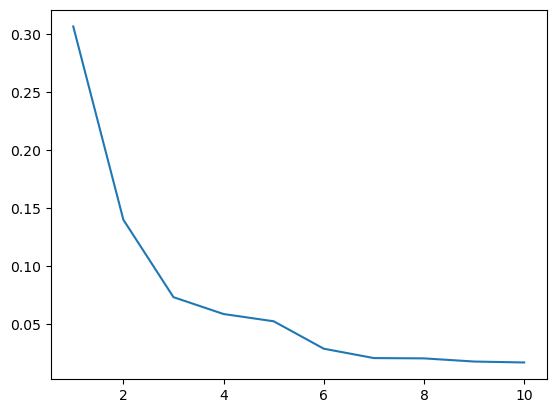

In [22]:
import matplotlib.pyplot as plt
plt.plot(range(1,11), variance_array)

Using the elbow method, we'll use 3 components. The first component explains 30.68% of the variance whereas the second component explains 14.00% of the variance, the third component explains 7.31% of the variance, Together, they cumulatively explain 51.99% of the variance. This is quite low and suggests PCA might not be too effective for this problem. 

In [23]:
from pyspark.ml.functions import array_to_vector, vector_to_array

train_final_df = model.transform(train_df)
val_final_df = model.transform(val_df)
test_final_df = model.transform(test_df)

train_final_df = train_final_df.withColumn("pca_features_3", array_to_vector(F.slice(vector_to_array("pca_features"), 1, 3)))
val_final_df = val_final_df.withColumn("pca_features_3", array_to_vector(F.slice(vector_to_array("pca_features"), 1, 3)))
test_final_df = test_final_df.withColumn("pca_features_3", array_to_vector(F.slice(vector_to_array("pca_features"), 1, 3)))

In [24]:
train_final_df.show(5)

+------------------+--------------------+-------+--------------------+--------------------+
|             label|            features|     id|        pca_features|      pca_features_3|
+------------------+--------------------+-------+--------------------+--------------------+
|           -6106.5|(73,[0,1,5,54,55,...|1530982|[-0.4371384552325...|[-0.4371384552325...|
|           -5470.0|(73,[0,1,47,54,56...|1725810|[0.53999690663074...|[0.53999690663074...|
|-5337.219999999999|(73,[0,1,51,53,55...|2828342|[-0.1698464774439...|[-0.1698464774439...|
|-5251.200000000001|(73,[0,1,2,53,60,...| 434357|[-0.3073044387205...|[-0.3073044387205...|
|           -5044.5|(73,[0,1,11,53,55...|1435141|[-0.6644550869383...|[-0.6644550869383...|
+------------------+--------------------+-------+--------------------+--------------------+
only showing top 5 rows



In [10]:
train_final_df.select("pca_features_3").first()

Row(pca_features_3=DenseVector([-0.4371, 0.8084, -0.7518]))

### Random Forest Model

In [11]:
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

train_final_df.select(["label", "pca_features_3"])

rf = RandomForestRegressor(labelCol="label", featuresCol="pca_features_3", predictionCol="prediction", numTrees=30, maxDepth=12, seed=SEED)
model_baseline = rf.fit(train_final_df)

In [12]:
model_baseline.save("models/rf_real_inctot_save.xml")

In [25]:
ev_rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
ev_mae = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")
ev_r2 = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")

pred_train = model_baseline.transform(train_final_df)
print("train_baseline rmse mae r2:", ev_rmse.evaluate(pred_train), ev_mae.evaluate(pred_train), ev_r2.evaluate(pred_train))
pred_val = model_baseline.transform(val_final_df)
print("val_baseline rmse mae r2:", ev_rmse.evaluate(pred_val), ev_mae.evaluate(pred_val), ev_r2.evaluate(pred_val))
pred_test = model_baseline.transform(test_final_df)
print("test_baseline rmse mae r2:", ev_rmse.evaluate(pred_test), ev_mae.evaluate(pred_test), ev_r2.evaluate(pred_test))

train_baseline rmse mae r2: 31994.744893190058 15028.175789801824 0.2349738178444033
val_baseline rmse mae r2: 31954.06607436491 15027.941916672142 0.23471556909480062
test_baseline rmse mae r2: 31868.15041080129 14998.545757016947 0.2355087786100768


In [26]:
pred_test.show(5)

+------------------+--------------------+-------+--------------------+--------------------+------------------+
|             label|            features|     id|        pca_features|      pca_features_3|        prediction|
+------------------+--------------------+-------+--------------------+--------------------+------------------+
|           -5044.5|(73,[0,1,11,54,55...|1435140|[-0.4296244789602...|[-0.4296244789602...|50768.327024666105|
|-4725.900000000001|(73,[0,1,5,53,55,...|1529169|[-0.8921947028587...|[-0.8921947028587...| 7605.713585104375|
|-4725.900000000001|(73,[0,1,5,54,55,...|1383435|[-0.5108653005803...|[-0.5108653005803...| 57803.01848751185|
|-4725.900000000001|(73,[0,1,5,54,58,...|1502086|[0.19386590639438...|[0.19386590639438...| 33190.02494430869|
|-4665.799999999999|(73,[0,1,2,54,57,...|1024049|[-0.1762593668071...|[-0.1762593668071...| 41134.61981242556|
+------------------+--------------------+-------+--------------------+--------------------+------------------+
o

In [34]:
pred_test = pred_test.withColumn("error", F.abs(F.col("label") - F.col("prediction")))
pred_test.show(5)

+------------------+--------------------+-------+--------------------+--------------------+------------------+------------------+
|             label|            features|     id|        pca_features|      pca_features_3|        prediction|             error|
+------------------+--------------------+-------+--------------------+--------------------+------------------+------------------+
|           -5044.5|(73,[0,1,11,54,55...|1435140|[-0.4296244789602...|[-0.4296244789602...|50768.327024666105|55812.827024666105|
|-4725.900000000001|(73,[0,1,5,53,55,...|1529169|[-0.8921947028587...|[-0.8921947028587...| 7605.713585104375|12331.613585104376|
|-4725.900000000001|(73,[0,1,5,54,55,...|1383435|[-0.5108653005803...|[-0.5108653005803...| 57803.01848751185| 62528.91848751185|
|-4725.900000000001|(73,[0,1,5,54,58,...|1502086|[0.19386590639438...|[0.19386590639438...| 33190.02494430869| 37915.92494430869|
|-4665.799999999999|(73,[0,1,2,54,57,...|1024049|[-0.1762593668071...|[-0.1762593668071...

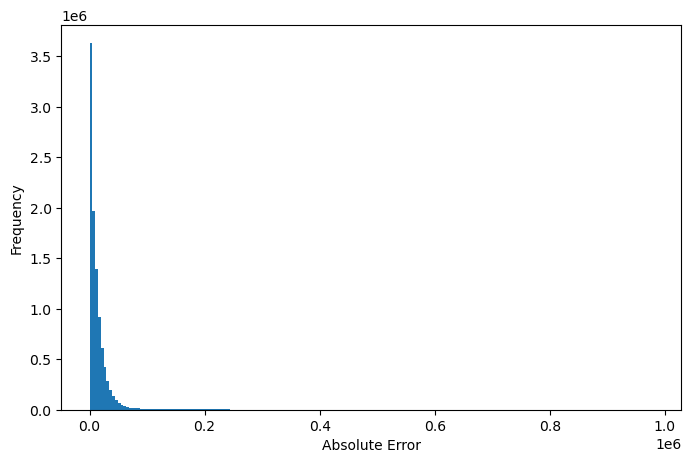

In [35]:
errors_rdd = pred_test.select("error").rdd.flatMap(lambda x: x)
bins, counts = errors_rdd.histogram(200)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(bins[:-1], counts, width=[bins[i+1]-bins[i] for i in range(len(bins)-1)], align='edge')

plt.xlabel("Absolute Error")
plt.ylabel("Frequency")

plt.show()

### Best predictions and Worst predictions

In [32]:
# Best prediction
best_row = pred_test.orderBy(F.col("error").asc()).limit(1)
best_row.select(["label", "prediction", "error"]).show()

+------+-----------------+--------------------+
| label|       prediction|               error|
+------+-----------------+--------------------+
|8328.0|8328.000394771372|1.558444362749301...|
+------+-----------------+--------------------+



In [33]:
# Best prediction arguments
id = best_row.select("id").first()[0]
df.filter(F.col("id") == id).select(["YEAR", "STATEFIP", "SEX", "AGE", "RACE", "EDUC", "EMPSTAT", "CITIZEN", "WKSWORK1", "MARRINYR", "HISPAN"]).show()

+------+--------+---+----+----+----+-------+-------+------------------+--------+------+
|  YEAR|STATEFIP|SEX| AGE|RACE|EDUC|EMPSTAT|CITIZEN|          WKSWORK1|MARRINYR|HISPAN|
+------+--------+---+----+----+----+-------+-------+------------------+--------+------+
|2016.0|     6.0|2.0|43.0| 1.0| 8.0|    3.0|    2.0|23.545506268163237|     1.0|   0.0|
+------+--------+---+----+----+----+-------+-------+------------------+--------+------+



In [36]:
# Worst prediction
worst_row = pred_test.orderBy(F.col("error").desc()).limit(1)
worst_row.select(["label", "prediction", "error"]).show()

+---------+-----------------+-----------------+
|    label|       prediction|            error|
+---------+-----------------+-----------------+
|1051676.0|72078.56791331651|979597.4320866835|
+---------+-----------------+-----------------+



In [37]:
# Worst prediction arguments
id = worst_row.select("id").first()[0]
df.filter(F.col("id") == id).select(["YEAR", "STATEFIP", "SEX", "AGE", "RACE", "EDUC", "EMPSTAT", "CITIZEN", "WKSWORK1", "MARRINYR", "HISPAN"]).show()

+------+--------+---+----+----+----+-------+-------+--------+--------+------+
|  YEAR|STATEFIP|SEX| AGE|RACE|EDUC|EMPSTAT|CITIZEN|WKSWORK1|MARRINYR|HISPAN|
+------+--------+---+----+----+----+-------+-------+--------+--------+------+
|2019.0|    36.0|1.0|74.0| 1.0|10.0|    1.0|    2.0|    52.0|     1.0|   0.0|
+------+--------+---+----+----+----+-------+-------+--------+--------+------+



## Training the new model to predict EDUC with PCA

In [11]:
from pyspark.ml.feature import VectorAssembler

SEED = 42

ml_df = df.select(F.col("EDUC").cast("double").alias("label"), "REALINCTOT_Z", "AGE_Z", "STATE_OH", "SEX_OH", "RACE_OH", "EMPSTAT_MM", "CITIZEN_MM", "MARRINYR_MM", "WKSWORK1_MM", "HISPAN_OH", "id")
assembler = VectorAssembler(inputCols=["REALINCTOT_Z", "AGE_Z", "STATE_OH", "SEX_OH", "RACE_OH", "EMPSTAT_MM", "CITIZEN_MM", "MARRINYR_MM", "WKSWORK1_MM", "HISPAN_OH"], outputCol="features")
ml_df = assembler.transform(ml_df)


In [12]:
ml_df = ml_df.select(["label", "features", "id"])
ml_df.show(5)

+-----+--------------------+---+
|label|            features| id|
+-----+--------------------+---+
|  6.0|(73,[0,1,2,53,55,...|  0|
|  7.0|(73,[0,1,2,54,61,...|  1|
|  7.0|(73,[0,1,2,53,61,...|  2|
|  0.0|(73,[0,1,2,53,61,...|  3|
|  6.0|(73,[0,1,2,54,58,...|  4|
+-----+--------------------+---+
only showing top 5 rows



### Getting class weights

In [13]:
ml_df.groupBy("label").count().collect()

[Row(label=8.0, count=4113044),
 Row(label=0.0, count=4282670),
 Row(label=7.0, count=7857403),
 Row(label=1.0, count=5186304),
 Row(label=4.0, count=1805252),
 Row(label=3.0, count=1611678),
 Row(label=2.0, count=4927072),
 Row(label=10.0, count=5871103),
 Row(label=6.0, count=19994469),
 Row(label=5.0, count=1934711),
 Row(label=9.0, count=9542074)]

In [14]:
total_count = ml_df.count()
class_counts = ml_df.groupBy("label").count().collect()
num_classes = len(class_counts)

weight_map = {row['label']: total_count / (num_classes * row['count']) for row in class_counts}
weight_map

{8.0: 1.4836562984406771,
 0.0: 1.424892330336831,
 7.0: 0.7766362036367024,
 1.0: 1.1766266760227777,
 4.0: 3.3803278635689846,
 3.0: 3.7863293017362256,
 2.0: 1.2385334812163566,
 10.0: 1.0393862339604052,
 6.0: 0.30520158531660113,
 5.0: 3.154137044945543,
 9.0: 0.6395196302568641}

In [15]:
mapping_weights = F.create_map([F.lit(x) for x in sum(weight_map.items(), ())])
ml_df = ml_df.withColumn("weight", mapping_weights[F.col("label")])
ml_df.show(5)

+-----+--------------------+---+-------------------+
|label|            features| id|             weight|
+-----+--------------------+---+-------------------+
|  6.0|(73,[0,1,2,53,55,...|  0|0.30520158531660113|
|  7.0|(73,[0,1,2,54,61,...|  1| 0.7766362036367024|
|  7.0|(73,[0,1,2,53,61,...|  2| 0.7766362036367024|
|  0.0|(73,[0,1,2,53,61,...|  3|  1.424892330336831|
|  6.0|(73,[0,1,2,54,58,...|  4|0.30520158531660113|
+-----+--------------------+---+-------------------+
only showing top 5 rows



### PCA

In [16]:
from pyspark.ml.feature import PCA

train_df, val_df, test_df = ml_df.randomSplit([0.70, 0.15, 0.15], seed=SEED)

pca = PCA(k=10, inputCol="features", outputCol="pca_features")
model = pca.fit(train_df)

variance_array = model.explainedVariance
print("Explained Variance: ", variance_array)


Explained Variance:  [0.24631880749554277,0.23439023874827744,0.10839776286302263,0.05659085091584266,0.0415915528670207,0.0319975654412624,0.022704370292810642,0.016251146439106974,0.013941038348908797,0.013278698290379977]


Matplotlib created a temporary cache directory at /scratch/elim1/job_49858841/matplotlib-amahij7f because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


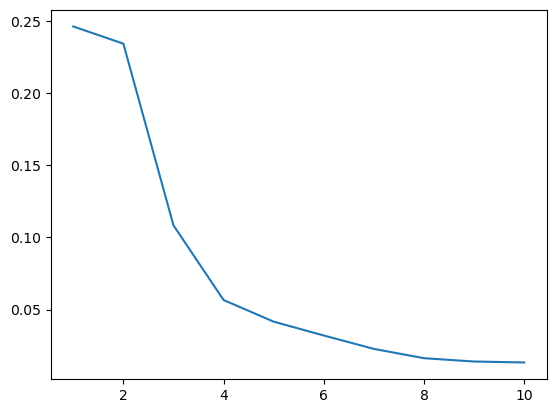

In [17]:
import matplotlib.pyplot as plt
plt.plot(range(1,11), variance_array)

Using the elbow method, we'll use 4 components. The first component explains 24.63% of the variance, the second component explains 23.44% of the variance, the third component explains 10.84% of the variance, and the fourth component explains 5.66%  of the variance. Together, they cumulatively explain 64.57% of the variance. Like the income model, this is quite low and suggests PCA might not be too effective for predicting education categories. 

In [18]:
from pyspark.ml.functions import array_to_vector, vector_to_array

train_final_df = model.transform(train_df)
val_final_df = model.transform(val_df)
test_final_df = model.transform(test_df)

train_final_df = train_final_df.withColumn("pca_features_4", array_to_vector(F.slice(vector_to_array("pca_features"), 1, 4)))
val_final_df = val_final_df.withColumn("pca_features_4", array_to_vector(F.slice(vector_to_array("pca_features"), 1, 4)))
test_final_df = test_final_df.withColumn("pca_features_4", array_to_vector(F.slice(vector_to_array("pca_features"), 1, 4)))

In [19]:
train_final_df.select("pca_features_4").first()

Row(pca_features_4=DenseVector([0.5726, -0.6666, -0.5813, 0.9537]))

### Random Forest Model

In [20]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

train_final_df.select(["label", "pca_features_4"])

rf = RandomForestClassifier(labelCol="label", featuresCol="features", weightCol="weight", predictionCol="prediction", numTrees=30, maxDepth=12, seed=SEED)
model_baseline_educ = rf.fit(train_df)

In [22]:
model_baseline_educ.save("models/rf_educ_save.xml")

In [23]:
ev_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
ev_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
ev_wp = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")

pred_train = model_baseline_educ.transform(train_df)
print("train_baseline", ev_acc.evaluate(pred_train), ev_f1.evaluate(pred_train), ev_wp.evaluate(pred_train))
pred_val = model_baseline_educ.transform(val_df)
print("val_baseline", ev_acc.evaluate(pred_val), ev_f1.evaluate(pred_val), ev_wp.evaluate(pred_val))
pred_test = model_baseline_educ.transform(test_df)
print("test_baseline", ev_acc.evaluate(pred_test), ev_f1.evaluate(pred_test), ev_wp.evaluate(pred_test))

train_baseline 0.37041628241604235 0.36648647835484655 0.43289119757259925
val_baseline 0.3704339375825032 0.3665760939290915 0.4332390940517039
test_baseline 0.3701301564101138 0.3662977633183852 0.43267263175486187


### Confusion Matrix

In [24]:
from pyspark.mllib.evaluation import MulticlassMetrics

preds_and_labels = pred_test.select(['prediction', 'label']).rdd.map(lambda x: (float(x[0]), float(x[1])))

metrics = MulticlassMetrics(preds_and_labels)

print(metrics.confusionMatrix().toArray())

/usr/local/spark/python/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


[[5.11940e+05 2.01250e+04 1.10170e+04 2.14880e+04 7.94300e+03 1.80460e+04
  2.16190e+04 7.60800e+03 4.93700e+03 7.48800e+03 9.54300e+03]
 [1.34735e+05 5.60194e+05 4.67020e+04 1.64010e+04 2.05700e+03 6.07200e+03
  6.30200e+03 1.64600e+03 9.80000e+02 1.56600e+03 2.07300e+03]
 [3.41000e+02 2.08600e+04 4.63358e+05 9.93150e+04 2.11910e+04 3.33950e+04
  6.49250e+04 9.40800e+03 7.78300e+03 5.65200e+03 1.43210e+04]
 [8.40000e+01 0.00000e+00 2.27690e+04 9.47510e+04 4.17030e+04 2.64990e+04
  3.25350e+04 7.13400e+03 6.52200e+03 1.97800e+03 7.70100e+03]
 [3.30000e+01 0.00000e+00 5.55500e+03 3.41020e+04 7.35360e+04 6.95710e+04
  4.87520e+04 1.23850e+04 1.12750e+04 2.70500e+03 1.21050e+04]
 [2.40000e+01 0.00000e+00 5.26100e+03 1.51380e+04 2.76290e+04 1.45920e+05
  4.73200e+04 1.90830e+04 1.33170e+04 2.68800e+03 1.33000e+04]
 [5.61000e+02 4.00000e+00 1.02503e+05 1.36853e+05 1.43409e+05 3.85929e+05
  8.44349e+05 3.25033e+05 4.33941e+05 8.87510e+04 5.39880e+05]
 [7.30000e+01 4.00000e+00 3.96970e+04 3.7

The following matrix is where each cell is the percentage of the total data.

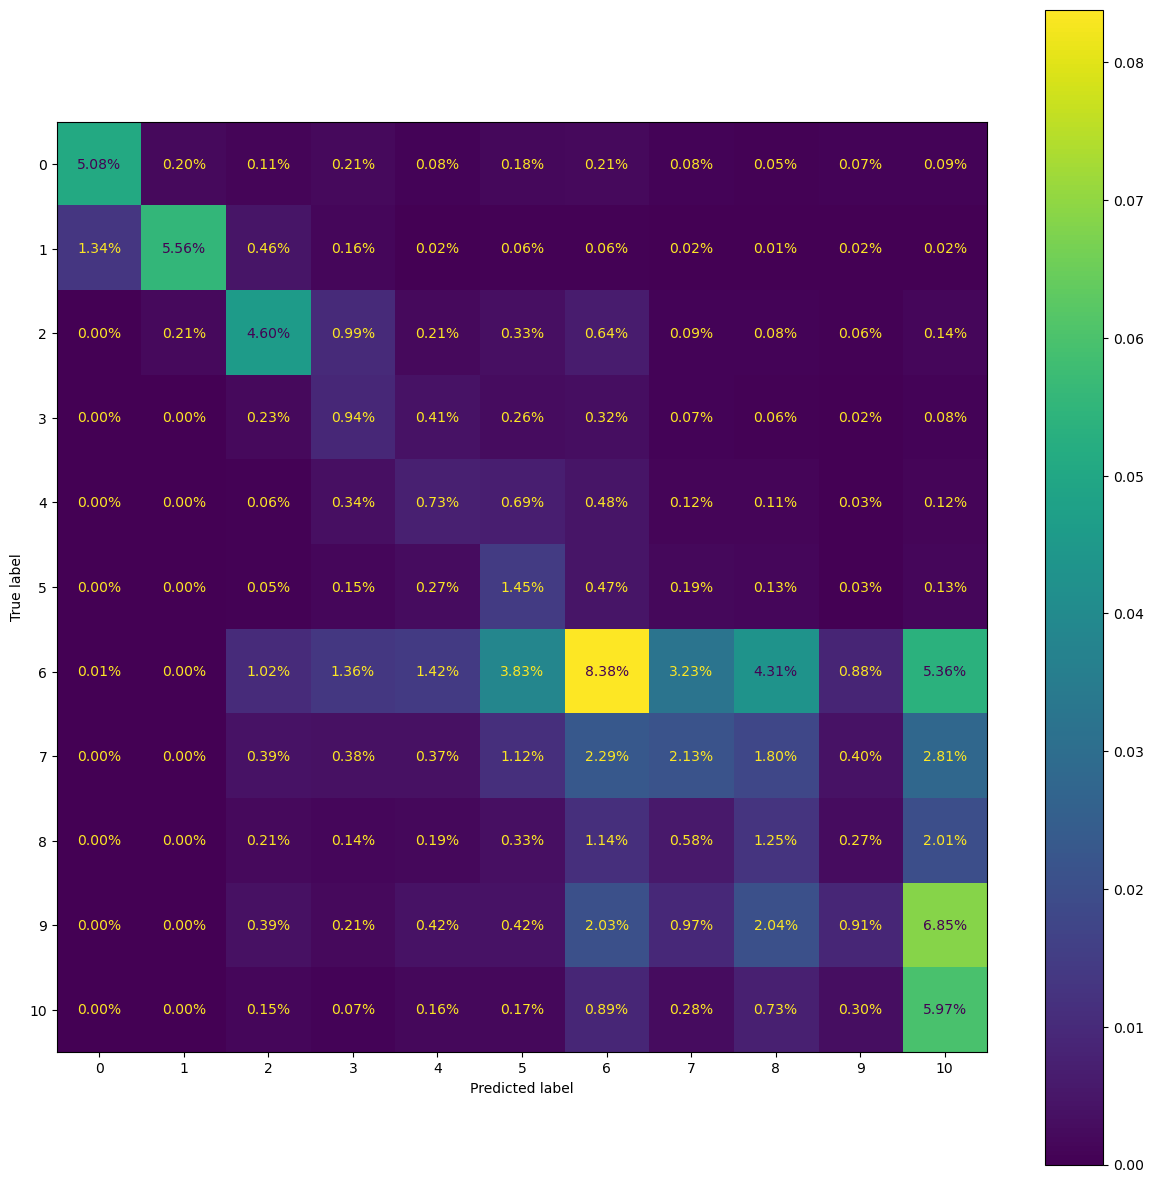

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
fig, ax = plt.subplots(figsize=(15, 15))
np_conf = metrics.confusionMatrix().toArray()
np_conf = np_conf / np.sum(np_conf)
disp = ConfusionMatrixDisplay(confusion_matrix=np_conf, display_labels=list(range(11)))
disp.plot(values_format='.2%', ax=ax)
plt.show()

The following matrix is subdivided into labels where each percentage is a percentage of the count of a certain true label (instead of all labels). For example, the bottom-left percentage is the percentage of cases that have a true label of 10 that were predicted as 0.

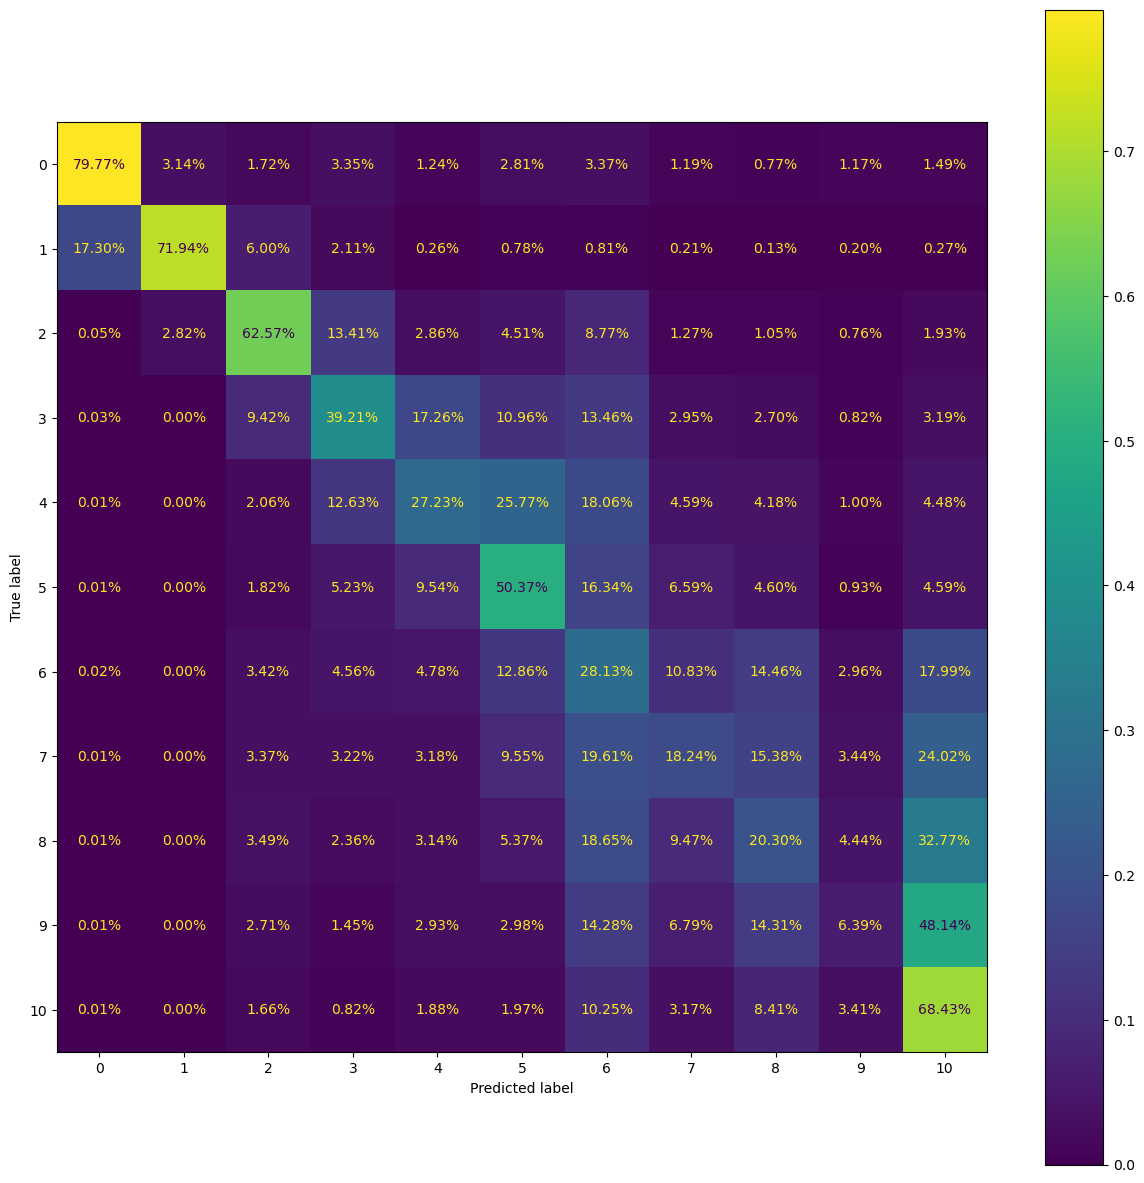

In [42]:
fig, ax = plt.subplots(figsize=(15, 15))
np_conf = metrics.confusionMatrix().toArray()
np_conf = np_conf / np.sum(np_conf, axis=1).reshape(-1, 1)
disp = ConfusionMatrixDisplay(confusion_matrix=np_conf, display_labels=list(range(11)))
disp.plot(values_format='.2%', ax=ax)
plt.show()

Correct Prediction

In [33]:
correct_pred = pred_test.filter(F.col('prediction') == F.col('label'))
correct_pred.show(1)

+-----+--------------------+------+-----------------+--------------------+--------------------+----------+
|label|            features|    id|           weight|       rawPrediction|         probability|prediction|
+-----+--------------------+------+-----------------+--------------------+--------------------+----------+
|  0.0|(73,[0,1,2,53,55,...|919513|1.424892330336831|[16.1902321063398...|[0.53967440354466...|       0.0|
+-----+--------------------+------+-----------------+--------------------+--------------------+----------+
only showing top 1 row



In [35]:
id = correct_pred.select("id").first()[0]
df.filter(F.col("id") == id).select(["YEAR", "STATEFIP", "SEX", "AGE", "RACE", "EDUC", "EMPSTAT", "CITIZEN", "WKSWORK1", "MARRINYR", "HISPAN", "id"]).show()

+------+--------+---+---+----+----+-------+-------+--------+--------+------+------+
|  YEAR|STATEFIP|SEX|AGE|RACE|EDUC|EMPSTAT|CITIZEN|WKSWORK1|MARRINYR|HISPAN|    id|
+------+--------+---+---+----+----+-------+-------+--------+--------+------+------+
|2022.0|     6.0|2.0|0.0| 1.0| 0.0|    1.0|    2.0|     0.0|     1.0|   0.0|919513|
+------+--------+---+---+----+----+-------+-------+--------+--------+------+------+



Incorrect Prediction

In [36]:
incor_pred = pred_test.filter(F.col('prediction') != F.col('label'))
incor_pred.show(1)

+-----+--------------------+-------+-----------------+--------------------+--------------------+----------+
|label|            features|     id|           weight|       rawPrediction|         probability|prediction|
+-----+--------------------+-------+-----------------+--------------------+--------------------+----------+
|  0.0|(73,[0,1,2,53,55,...|1127478|1.424892330336831|[0.69766900212138...|[0.02325563340404...|       6.0|
+-----+--------------------+-------+-----------------+--------------------+--------------------+----------+
only showing top 1 row



In [37]:
id = incor_pred.select("id").first()[0]
df.filter(F.col("id") == id).select(["YEAR", "STATEFIP", "SEX", "AGE", "RACE", "EDUC", "EMPSTAT", "CITIZEN", "WKSWORK1", "MARRINYR", "HISPAN", "id"]).show()

+------+--------+---+----+----+----+-------+-------+--------+--------+------+-------+
|  YEAR|STATEFIP|SEX| AGE|RACE|EDUC|EMPSTAT|CITIZEN|WKSWORK1|MARRINYR|HISPAN|     id|
+------+--------+---+----+----+----+-------+-------+--------+--------+------+-------+
|2021.0|     6.0|2.0|71.0| 1.0| 0.0|    3.0|    2.0|     0.0|     2.0|   0.0|1127478|
+------+--------+---+----+----+----+-------+-------+--------+--------+------+-------+

